# 1. Introduction

## Project Overview

This project implements a complete machine learning pipeline for multiclass vehicle classification using the Statlog Vehicle Silhouettes dataset from the UCI Machine Learning Repository.

The main objective is to compare different machine learning approaches and evaluate how preprocessing, dimensionality reduction, and ensemble methods affect model performance.

The project includes:

- Data preprocessing and feature scaling
- Correlation analysis and feature selection
- Logistic Regression with hyperparameter tuning
- Principal Component Analysis (PCA)
- Decision Tree classification
- Bagging ensembles
- Random Forest
- ROC curve analysis for multiclass classification
- Learning curve analysis

## Dataset Description

The Statlog Vehicle Silhouettes dataset contains geometric features extracted from vehicle silhouettes. The classification task consists of predicting the vehicle type based on shape-related numerical features.

Vehicle classes:

- bus
- opel
- saab
- van

The dataset contains 18 numerical features describing geometric properties such as compactness, circularity, rectangularity, skewness, kurtosis, and elongation.

# 2. Data Loading

## Data Import

The dataset is distributed across multiple `.dat` files. In this section, all files are loaded and combined into a single pandas DataFrame.

After loading the data, column names are assigned according to the dataset documentation.

In [20]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [3]:
DATA_DIR = Path("/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data")

data_files = sorted(DATA_DIR.glob("*.dat"))

data_files

[PosixPath('/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data/xaa.dat'),
 PosixPath('/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data/xab.dat'),
 PosixPath('/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data/xac.dat'),
 PosixPath('/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data/xad.dat'),
 PosixPath('/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data/xae.dat'),
 PosixPath('/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data/xaf.dat'),
 PosixPath('/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data/xag.dat'),
 PosixPath('/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data/xah.dat'),
 PosixPath('/Users/olgah/code/python/vehicle-silhouettes-ml-pipeline/data/xai.dat')]

In [4]:
dfs = []

for file in data_files:
    df_part = pd.read_csv(
        file,
        sep=r"\s+",
        header=None
    )
    
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus


In [5]:
columns = [
    "compactness",
    "circularity",
    "distance_circularity",
    "radius_ratio",
    "pr_axis_aspect_ratio",
    "max_length_aspect_ratio",
    "scatter_ratio",
    "elongatedness",
    "pr_axis_rectangularity",
    "max_length_rectangularity",
    "scaled_variance_major",
    "scaled_variance_minor",
    "scaled_radius_gyration",
    "skewness_major",
    "skewness_minor",
    "kurtosis_major",
    "kurtosis_minor",
    "hollows_ratio",
    "class"
]

df.columns = columns

df.head()

,compactness,circularity,distance_circularity,radius_ratio,pr_axis_aspect_ratio,max_length_aspect_ratio,scatter_ratio,elongatedness,pr_axis_rectangularity,max_length_rectangularity,scaled_variance_major,scaled_variance_minor,scaled_radius_gyration,skewness_major,skewness_minor,kurtosis_major,kurtosis_minor,hollows_ratio,class
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   compactness                846 non-null    int64
 1   circularity                846 non-null    int64
 2   distance_circularity       846 non-null    int64
 3   radius_ratio               846 non-null    int64
 4   pr_axis_aspect_ratio       846 non-null    int64
 5   max_length_aspect_ratio    846 non-null    int64
 6   scatter_ratio              846 non-null    int64
 7   elongatedness              846 non-null    int64
 8   pr_axis_rectangularity     846 non-null    int64
 9   max_length_rectangularity  846 non-null    int64
 10  scaled_variance_major      846 non-null    int64
 11  scaled_variance_minor      846 non-null    int64
 12  scaled_radius_gyration     846 non-null    int64
 13  skewness_major             846 non-null    int64
 14  skewness_minor             846 non-nu

In [7]:
df.describe()

,compactness,circularity,distance_circularity,radius_ratio,pr_axis_aspect_ratio,max_length_aspect_ratio,scatter_ratio,elongatedness,pr_axis_rectangularity,max_length_rectangularity,scaled_variance_major,scaled_variance_minor,scaled_radius_gyration,skewness_major,skewness_minor,kurtosis_major,kurtosis_minor,hollows_ratio
count,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.00000,846.000000,846.000000,846.000000,846.000000,846.000000
mean,93.678487,44.861702,82.088652,168.940898,61.693853,8.567376,168.839243,40.933806,20.582742,147.998818,188.625296,439.911348,174.70331,72.462175,6.377069,12.599291,188.932624,195.632388
std,8.234474,6.169866,15.771533,33.472183,7.888251,4.601217,33.244978,7.811560,2.592138,14.515652,31.394837,176.692614,32.54649,7.486974,4.918353,8.931240,6.163949,7.438797
min,73.000000,33.000000,40.000000,104.000000,47.000000,2.000000,112.000000,26.000000,17.000000,118.000000,130.000000,184.000000,109.00000,59.000000,0.000000,0.000000,176.000000,181.000000
25%,87.000000,40.000000,70.000000,141.000000,57.000000,7.000000,146.250000,33.000000,19.000000,137.000000,167.000000,318.250000,149.00000,67.000000,2.000000,5.000000,184.000000,190.250000
50%,93.000000,44.000000,80.000000,167.000000,61.000000,8.000000,157.000000,43.000000,20.000000,146.000000,178.500000,364.000000,173.00000,71.500000,6.000000,11.000000,188.000000,197.000000
75%,100.000000,49.000000,98.000000,195.000000,65.000000,10.000000,198.000000,46.000000,23.000000,159.000000,217.000000,587.000000,198.00000,75.000000,9.000000,19.000000,193.000000,201.000000
max,119.000000,59.000000,112.000000,333.000000,138.000000,55.000000,265.000000,61.000000,29.000000,188.000000,320.000000,1018.000000,268.00000,135.000000,22.000000,41.000000,206.000000,211.000000


In [8]:
df["class"].value_counts()

class
bus     218
saab    217
opel    212
van     199
Name: count, dtype: int64

## Data Loading Summary

The dataset was successfully loaded from multiple `.dat` files and combined into a single DataFrame.

The final dataset contains 846 observations, 18 numerical features, and one target variable.

There are no missing values in the dataset. The target classes are relatively balanced, which allows us to use accuracy and macro F1-score for model evaluation.

# 3. Exploratory Data Analysis

## Exploratory Data Analysis

In this section, the dataset structure and feature distributions are explored.

The following analyses are performed:

- Dataset shape inspection
- Feature type analysis
- Missing value detection
- Class distribution analysis
- Correlation analysis
- Feature distribution visualization

The purpose of EDA is to better understand the dataset before model training and preprocessing.

In [9]:
df.isnull().sum()

compactness                  0
circularity                  0
distance_circularity         0
radius_ratio                 0
pr_axis_aspect_ratio         0
max_length_aspect_ratio      0
scatter_ratio                0
elongatedness                0
pr_axis_rectangularity       0
max_length_rectangularity    0
scaled_variance_major        0
scaled_variance_minor        0
scaled_radius_gyration       0
skewness_major               0
skewness_minor               0
kurtosis_major               0
kurtosis_minor               0
hollows_ratio                0
class                        0
dtype: int64

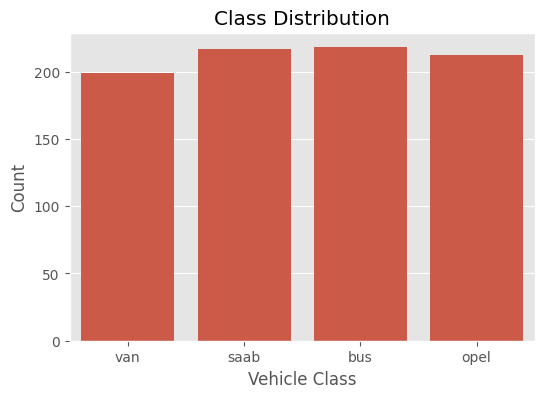

In [10]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="class"
)

plt.title("Class Distribution")
plt.xlabel("Vehicle Class")
plt.ylabel("Count")

plt.show()

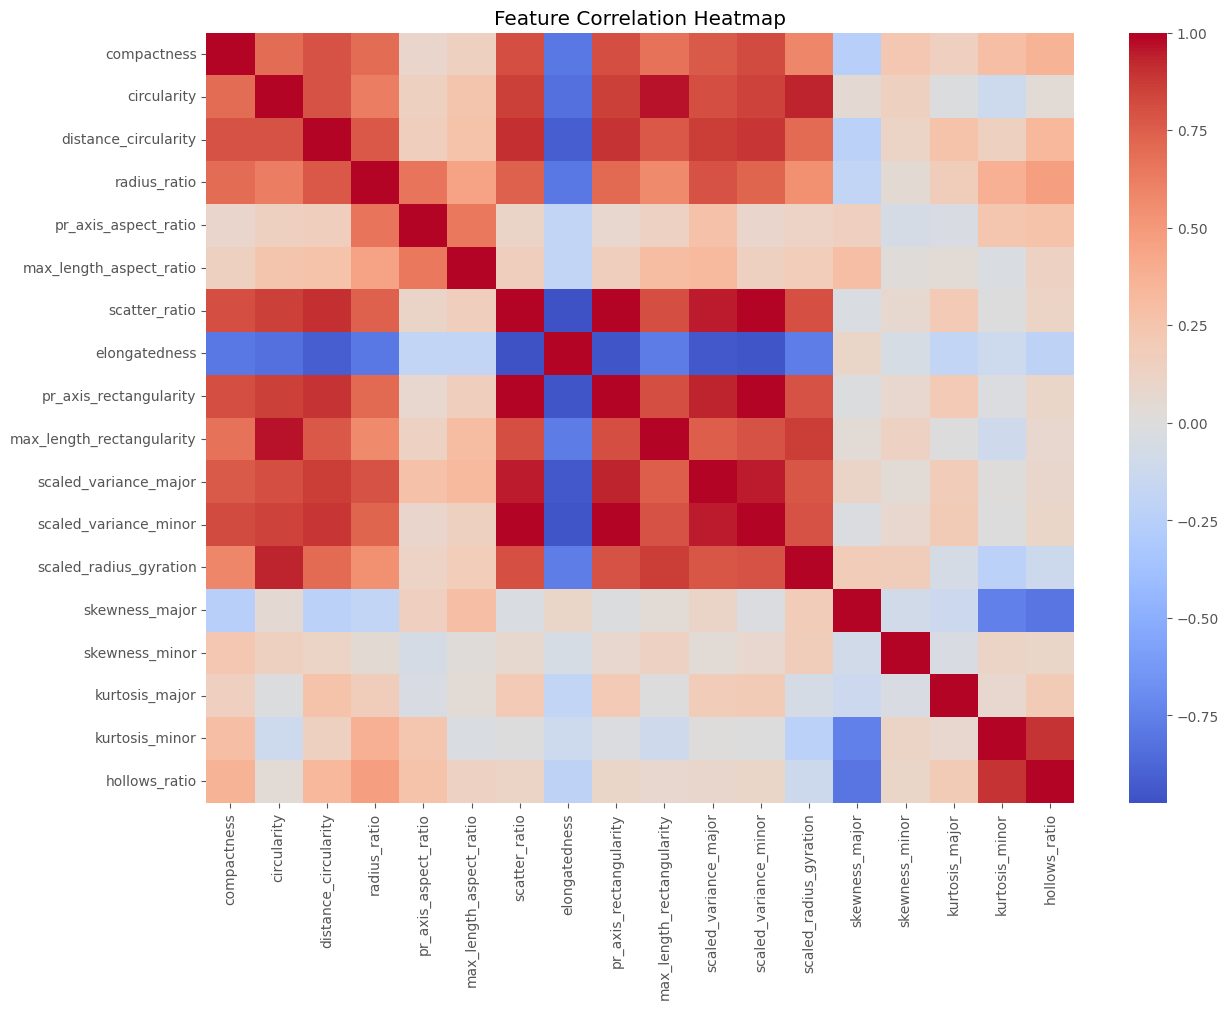

In [11]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df.drop(columns="class").corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

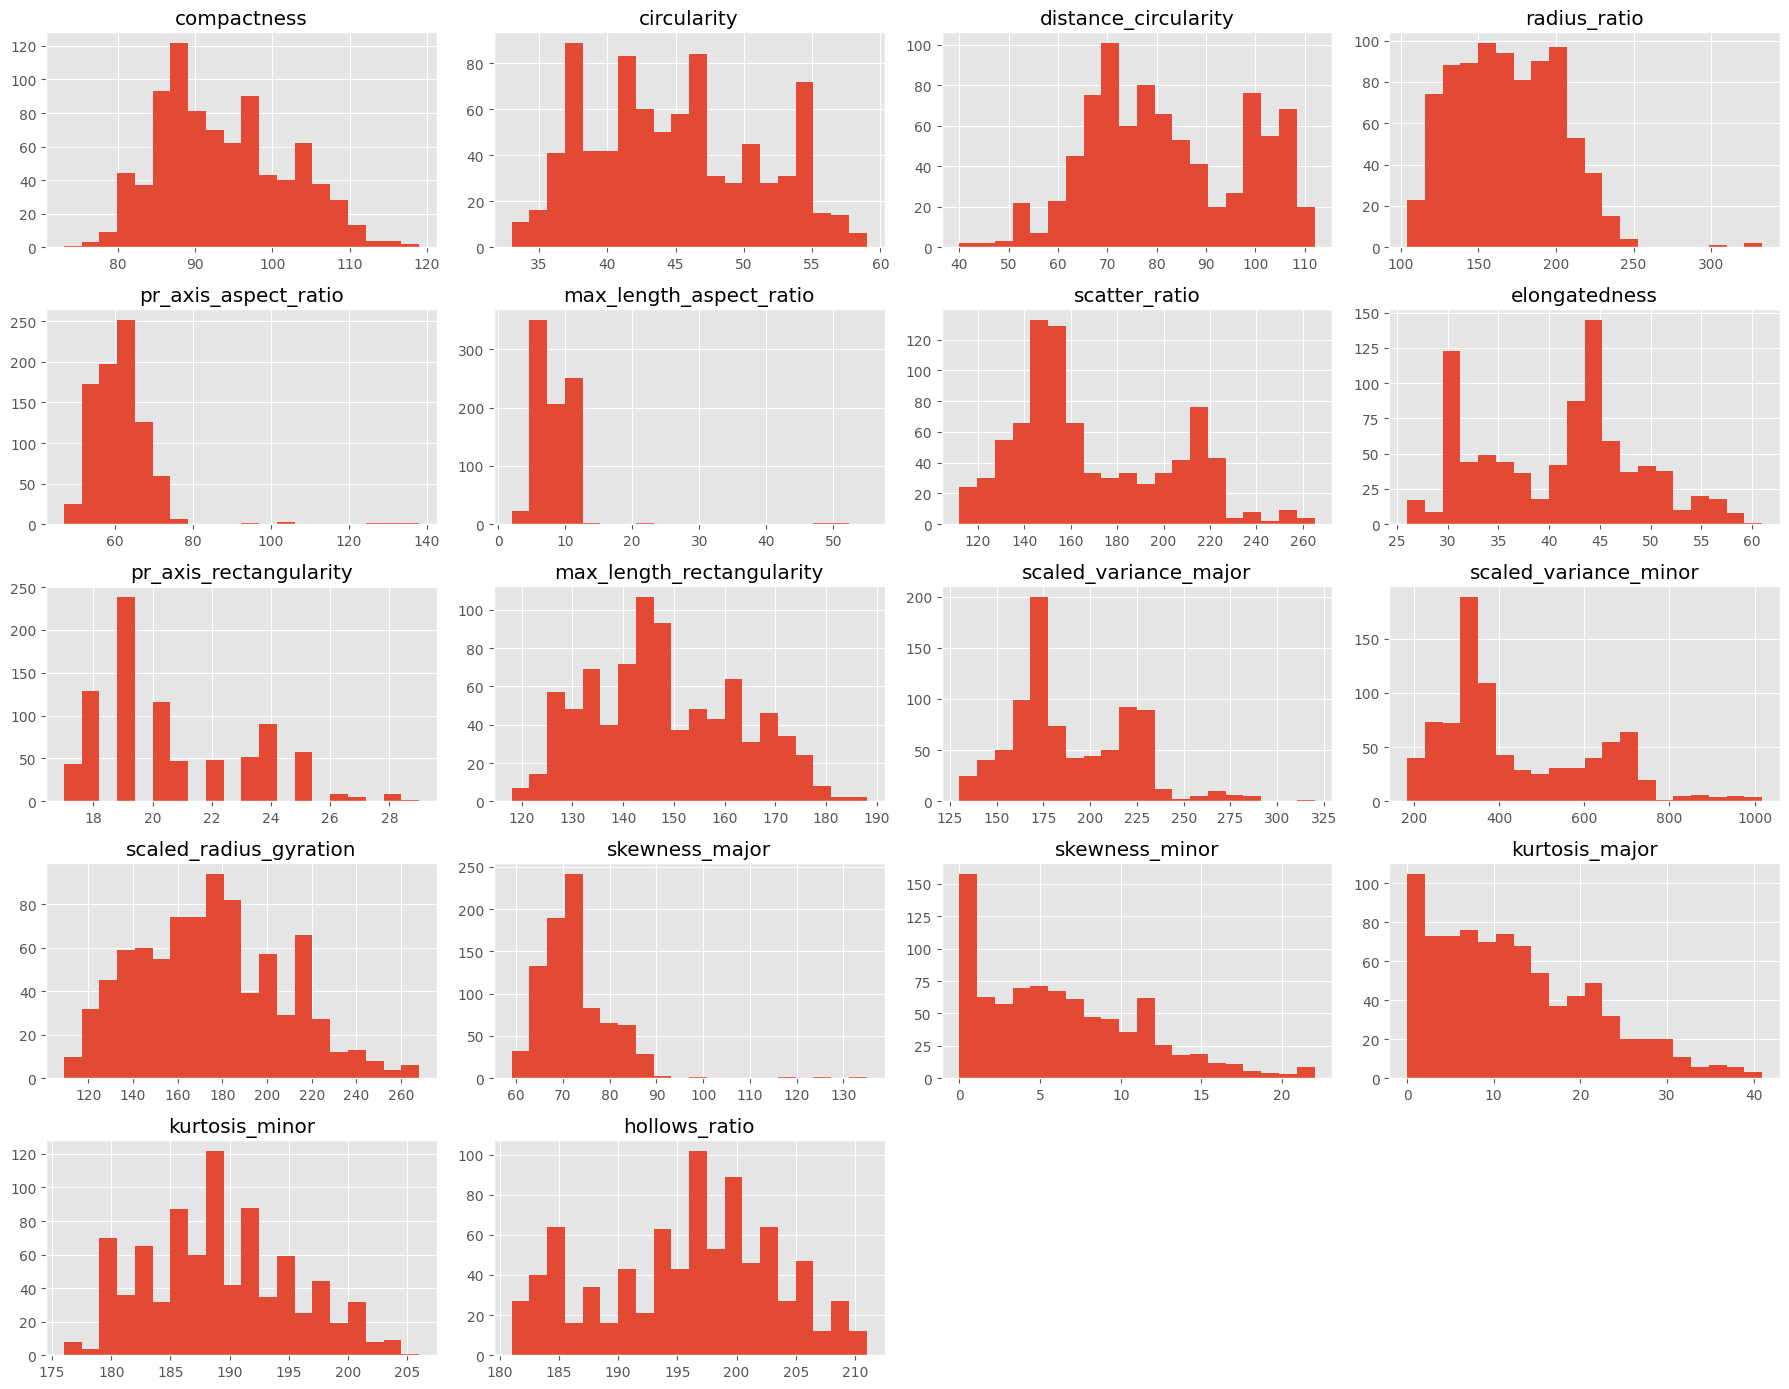

In [12]:
df.drop(columns="class").hist(
    figsize=(18, 14),
    bins=20
)

plt.tight_layout()
plt.show()

## Feature Distribution Analysis

The feature distributions show noticeable differences in scale across variables. Some features have values in relatively small ranges, while others span much larger intervals.

Several variables also exhibit skewed distributions and potential outliers, which is common for geometric and moment-based descriptors.

These observations further justify the use of feature scaling before applying Logistic Regression and PCA.

The multimodal structure observed in some features may indicate class-specific geometric patterns that can be useful for classification.

# 4. Data Preprocessing

## Train-Test Split and Feature Scaling

Before training machine learning models, the dataset is split into training and testing subsets.

Feature scaling is applied using `StandardScaler` because Logistic Regression and PCA are sensitive to differences in feature magnitude.

The preprocessing pipeline also includes correlation analysis and removal of highly correlated features to reduce multicollinearity.

In [13]:
X = df.drop(columns="class")

y = df["class"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (676, 18)
X_test shape: (170, 18)
y_train shape: (676,)
y_test shape: (170,)


In [16]:
corr_matrix = X_train.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.9)
]

high_corr_features

['scatter_ratio',
 'elongatedness',
 'pr_axis_rectangularity',
 'max_length_rectangularity',
 'scaled_variance_major',
 'scaled_variance_minor',
 'scaled_radius_gyration']

In [17]:
X_train_reduced = X_train.drop(columns=high_corr_features)
X_test_reduced = X_test.drop(columns=high_corr_features)

X_train_reduced.shape, X_test_reduced.shape

((676, 11), (170, 11))

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_reduced)

X_test_scaled = scaler.transform(X_test_reduced)

In [19]:
print("Removed highly correlated features:")
for feature in high_corr_features:
    print("-", feature)

Removed highly correlated features:
- scatter_ratio
- elongatedness
- pr_axis_rectangularity
- max_length_rectangularity
- scaled_variance_major
- scaled_variance_minor
- scaled_radius_gyration


## Feature Selection Results

Several highly correlated features were identified and removed using a correlation threshold of 0.9.

The removed variables were mainly variance-related and geometric descriptors that contained redundant information.

After feature selection, the number of features was reduced from 18 to 11, helping decrease multicollinearity while preserving the majority of the dataset information.

# 5. Logistic Regression

## Logistic Regression Baseline

Logistic Regression is used as the first baseline model.

The model is trained on preprocessed data after correlation-based feature selection and feature scaling.

Model performance is evaluated using accuracy and macro F1-score.

## Logistic Regression Overview

Logistic Regression is a linear classification model that estimates class probabilities using a weighted combination of input features.

The model computes a linear score:

$$
z = w_1x_1 + w_2x_2 + \dots + w_nx_n + b
$$

where:

- $x_i$ are input features,
- $w_i$ are model weights,
- $b$ is the bias term.

In [ ]:
logreg_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

## Probability Estimation

The linear score is transformed into probabilities using nonlinear activation functions.

For binary classification, Logistic Regression uses the sigmoid function:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

For multiclass classification, the softmax function is used:

$$
P(y=i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
$$

which converts model scores into normalized class probabilities.

In [ ]:
logreg_baseline.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [22]:
y_pred_logreg_baseline = logreg_baseline.predict(X_test_scaled)

## Optimization and Loss Function

During training, the model parameters are optimized by minimizing the classification loss function.

For binary classification, Logistic Regression minimizes the binary cross-entropy loss:

$$
L(y, \hat{y}) =
-\left[
y \log(\hat{y})
+
(1-y)\log(1-\hat{y})
\right]
$$

where:

- $y$ is the true class label,
- $\hat{y}$ is the predicted probability produced by the model.

For multiclass classification, categorical cross-entropy loss is used:

$$
L = -\sum_{i=1}^{K} y_i \log(\hat{y}_i)
$$

where:

- $K$ is the number of classes,
- $y_i$ is the true class indicator,
- $\hat{y}_i$ is the predicted probability for class $i$.

The optimization algorithm iteratively updates model weights to minimize prediction error on the training data.

In [23]:
logreg_baseline_accuracy = accuracy_score(y_test, y_pred_logreg_baseline)
logreg_baseline_f1 = f1_score(y_test, y_pred_logreg_baseline, average="macro")

print("Baseline Logistic Regression")
print("Accuracy:", round(logreg_baseline_accuracy, 4))
print("Macro F1-score:", round(logreg_baseline_f1, 4))

Baseline Logistic Regression
Accuracy: 0.7647
Macro F1-score: 0.7641


In [24]:
print(classification_report(y_test, y_pred_logreg_baseline))

              precision    recall  f1-score   support

         bus       0.87      0.91      0.89        44
        opel       0.61      0.55      0.57        42
        saab       0.66      0.70      0.68        44
         van       0.92      0.90      0.91        40

    accuracy                           0.76       170
   macro avg       0.76      0.77      0.76       170
weighted avg       0.76      0.76      0.76       170



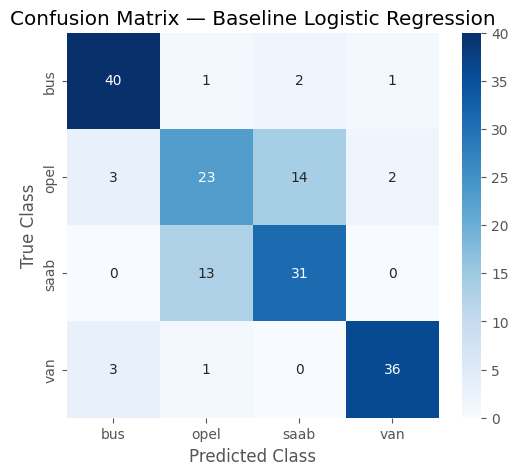

In [25]:
conf_matrix = confusion_matrix(y_test, y_pred_logreg_baseline)

plt.figure(figsize=(6, 5))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=logreg_baseline.classes_,
    yticklabels=logreg_baseline.classes_
)

plt.title("Confusion Matrix — Baseline Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.show()

## Confusion Matrix Analysis

The confusion matrix shows that the model performs very well on the `bus` and `van` classes, with most samples classified correctly.

The largest source of error occurs between the `opel` and `saab` classes. Many `opel` samples are predicted as `saab`, and vice versa.

This result is consistent with the dataset documentation, which states that the two car classes are more difficult to distinguish because of their similar geometric characteristics.

# 6. PCA

## Principal Component Analysis (PCA)

Principal Component Analysis is applied to reduce feature dimensionality and analyze variance distribution across components.

Before applying PCA, the data is scaled using `StandardScaler`.

The following steps are performed:

- PCA fitting on training data only
- Explained variance analysis
- Selection of the optimal number of components
- Logistic Regression training on PCA-transformed data

The purpose of PCA is to investigate whether dimensionality reduction improves model performance and reduces feature redundancy.

# 7. Decision Tree

## Decision Tree Classification

A Decision Tree classifier is trained and optimized using cross-validation.

The optimal tree depth is selected using `GridSearchCV`.

Model performance is evaluated using:

- Accuracy
- F1-score

The Decision Tree model is compared with Logistic Regression to analyze the impact of nonlinear decision boundaries.

# 8. Bagging

## Bagging Ensembles

Bagging ensembles are applied to improve model stability and reduce variance.

Two ensemble configurations are investigated:

- Bagging with Logistic Regression
- Bagging with Decision Trees

The influence of the number of estimators on model performance is analyzed using:

- Accuracy curves
- F1-score curves

The goal is to determine whether ensemble methods improve classification performance compared to single models.

# 9. Random Forest

## Random Forest Classification

Random Forest is trained as an advanced ensemble learning method based on multiple decision trees.

The influence of the number of trees on model quality is analyzed.

Model evaluation includes:

- Accuracy
- F1-score

Performance trends are visualized to identify the optimal number of trees and evaluate ensemble effectiveness.

# 10. Learning Curves

## Learning Curve Analysis

Learning curves are used to analyze how model performance changes as the size of the training dataset increases.

The training data is divided into multiple subsets of increasing size.

For each subset, models are trained and evaluated using:

- Accuracy
- F1-score

This analysis helps determine:

- Whether the models benefit from additional data
- Whether underfitting or overfitting is present
- How model stability changes with dataset size

# 11. Final Conclusions

## Final Conclusions

In this section, the performance of all trained models is summarized and compared.

The analysis focuses on:

- The impact of preprocessing
- The effectiveness of PCA
- The benefits of ensemble learning
- Model stability and generalization performance

The best-performing model is identified based on evaluation metrics and overall behavior across experiments.